In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Read dataset (raw CSV)
df = pd.read_csv(r"C:\Users\Lidiya Getale\Downloads\data\data\benin-malanville.csv")





In [2]:
print("Summary Statistics:")
display(df.describe())

print("\nMissing Values Per Column:")
display(df.isna().sum())

# Columns with more than 5% missing
missing_cols = df.columns[df.isna().sum()/len(df) > 0.05]
print("\nColumns with >5% missing values:", missing_cols.tolist())


Summary Statistics:


,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,240.559452,167.187516,115.358961,236.589496,228.883576,28.179683,54.487969,2.121113,2.809195,0.473390,153.435172,8.582407,994.197199,0.000923,0.001905,35.246026,32.471736,NaN
std,331.131327,261.710501,158.691074,326.894859,316.536515,5.924297,28.073069,1.603466,2.029120,0.273395,102.332842,6.385864,2.474993,0.030363,0.037115,14.807258,12.348743,NaN
min,-12.900000,-7.800000,-12.600000,0.000000,0.000000,11.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,985.000000,0.000000,0.000000,9.000000,8.100000,NaN
25%,-2.000000,-0.500000,-2.100000,0.000000,0.000000,24.200000,28.800000,1.000000,1.300000,0.400000,59.000000,3.700000,993.000000,0.000000,0.000000,24.200000,23.600000,NaN
50%,1.800000,-0.100000,1.600000,4.500000,4.300000,28.000000,55.100000,1.900000,2.600000,0.500000,181.000000,8.600000,994.000000,0.000000,0.000000,30.000000,28.900000,NaN
75%,483.400000,314.200000,216.300000,463.700000,447.900000,32.300000,80.100000,3.100000,4.100000,0.600000,235.100000,12.300000,996.000000,0.000000,0.000000,46.900000,41.500000,NaN
max,1413.000000,952.300000,759.200000,1342.300000,1342.300000,43.800000,100.000000,19.500000,26.600000,4.200000,360.000000,99.400000,1003.000000,1.000000,2.500000,81.000000,72.500000,NaN



Missing Values Per Column:


Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64


Columns with >5% missing values: ['Comments']


In [3]:
import numpy as np
from scipy import stats

# Select columns for outlier detection
cols_to_check = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

# Compute Z-scores
z_scores = np.abs(stats.zscore(df[cols_to_check], nan_policy='omit'))

# Flag outliers where |Z| > 3
outliers = (z_scores > 3)
print("Outliers per column:")
print(outliers.sum())

# Count how many rows have any outlier
print("\nTotal rows with any outlier:", outliers.any(axis=1).sum())


Outliers per column:
10526

Total rows with any outlier: 7740


In [4]:
# Fill missing values in key numeric columns with median
for col in cols_to_check:
    if df[col].isna().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

print("✅ Missing values handled (using median imputation).")


✅ Missing values handled (using median imputation).


In [5]:
import os

os.makedirs("data", exist_ok=True)
df.to_csv("data/benin_clean.csv", index=False)
print("✅ Cleaned dataset saved to data/benin_clean.csv")


✅ Cleaned dataset saved to data/benin_clean.csv


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(df['Timestamp'], df['GHI'], label='GHI')
plt.plot(df['Timestamp'], df['DNI'], label='DNI')
plt.plot(df['Timestamp'], df['DHI'], label='DHI')
plt.xlabel('Timestamp')
plt.ylabel('Irradiance (W/m²)')
plt.title('Solar Irradiance Over Time (Benin)')
plt.legend()
plt.show()


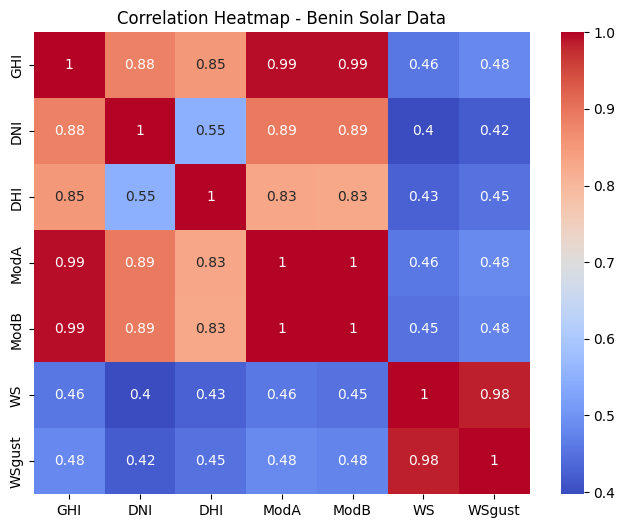

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df[cols_to_check].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap - Benin Solar Data')
plt.show()
